# 03. Statistical Analysis

This notebook builds on the exploratory data analysis by applying statistical methods to quantify relationships and differences observed in the used-car dataset.

The analysis focuses on descriptive statistics, correlations, group comparisons, hypothesis testing, and simple linear regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from used_cars_analysis.data import find_project_root
from used_cars_analysis.analysis import transmission_price_test, age_price_regression

PROJECT_ROOT = find_project_root()
CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "cleaned_car_data.csv"
IMAGES_DIR = PROJECT_ROOT / "images" / "generated"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

if not CLEAN_DATA_PATH.exists():
    raise FileNotFoundError(
        f"{CLEAN_DATA_PATH} was not found. Run notebooks/01_data_inspection.ipynb first to generate it."
    )

df = pd.read_csv(CLEAN_DATA_PATH)

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,13
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,13
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,8
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,3
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,6


## 01. Descriptive Statistics

These summaries establish the scale and spread of the numerical variables before formal tests are applied. The mean, median, standard deviation, and range also help identify skewed variables and possible outliers.

In [2]:
numeric_columns = [
    "year",
    "selling_price",
    "km_driven",
    "car_age"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
year,3577.0,2012.962538,4.251759,1992.0,2010.0,2013.0,2016.0,2020.0
selling_price,3577.0,473912.542074,509301.809816,20000.0,200000.0,350000.0,600000.0,8900000.0
km_driven,3577.0,69250.545709,47579.940016,1.0,36000.0,60000.0,90000.0,806599.0
car_age,3577.0,7.037462,4.251759,0.0,4.0,7.0,10.0,28.0


In [3]:
summary = df[numeric_columns].agg(
    ["mean", "median", "std", "min", "max"]
).T

summary

,mean,median,std,min,max
year,2012.962538,2013.0,4.251759,1992.0,2020.0
selling_price,473912.542074,350000.0,509301.809816,20000.0,8900000.0
km_driven,69250.545709,60000.0,47579.940016,1.0,806599.0
car_age,7.037462,7.0,4.251759,0.0,28.0


## 02. Correlation with Selling Price

The correlations below identify which numerical variables move most closely with selling price. These are associations used to motivate the formal Pearson test and regression that follow.

In [4]:
price_correlations = (
    df[numeric_columns]
    .corr()["selling_price"]
    .drop("selling_price")
    .sort_values(key=abs, ascending=False)
)

price_correlations

car_age     -0.424260
year         0.424260
km_driven   -0.187359
Name: selling_price, dtype: float64

## 03. Transmission Price Difference

This section compares selling prices for manual and automatic vehicles. Welch's independent two-sample t-test is used because it does not assume equal variance between the groups, and Cohen's d measures the practical size of the difference.

In [5]:
transmission_results = transmission_price_test(df)

print(f"Manual vehicles: {transmission_results['manual_sample_size']:,}")
print(f"Automatic vehicles: {transmission_results['automatic_sample_size']:,}")
print(f"Manual mean price: {transmission_results['manual_mean_price']:,.0f}")
print(f"Automatic mean price: {transmission_results['automatic_mean_price']:,.0f}")

print("t-statistic:", transmission_results["welch_t_statistic"])
print("p-value:", transmission_results["p_value"])

Manual vehicles: 3,265
Automatic vehicles: 312
Manual mean price: 397,366
Automatic mean price: 1,274,955
t-statistic: 12.853660631622327
p-value: 1.1267181794851259e-30


In [6]:
alpha = 0.05

if transmission_results["p_value"] < alpha:
    print("The difference is statistically significant at the 5% level.")
else:
    print("The difference is not statistically significant at the 5% level.")

The difference is statistically significant at the 5% level.


In [7]:
# Cohen's d effect size, computed once inside transmission_price_test()
cohens_d = transmission_results["cohens_d"]

print("Cohen's d:", cohens_d)
print(
    f"Cohen's d = {cohens_d:.2f}, indicating a very large difference "
    "in selling prices between automatic and manual vehicles."
)

Cohen's d: 1.9716910478157972
Cohen's d = 1.97, indicating a very large difference in selling prices between automatic and manual vehicles.


## 04. Hypothesis Testing: Car Age and Selling Price

This section tests whether there is a statistically significant linear relationship between car age and selling price.

- **Null hypothesis (H₀):** There is no linear correlation between car age and selling price in the population.
- **Alternative hypothesis (H₁):** There is a linear correlation between car age and selling price in the population.

A Pearson correlation test is used with a significance level of 5%.

In [8]:
age_correlation, age_p_value = stats.pearsonr(
    df["car_age"],
    df["selling_price"]
)

print(f"Pearson correlation: {age_correlation:.3f}")
print(f"p-value: {age_p_value:.4g}")

Pearson correlation: -0.424
p-value: 2.77e-156


### Hypothesis Testing Conclusion

The Pearson correlation test found a statistically significant negative linear relationship between car age and selling price (r = -0.424, p < 0.001).

This indicates that older vehicles tend to have lower selling prices in this dataset. The correlation is moderate rather than strong, meaning car age explains only part of the variation in selling prices.

The result shows an association and does not establish that increasing car age directly causes a decrease in selling price.

Slope: -50,820.48
Intercept: 831,559.70
R-squared: 0.180
p-value: 2.77e-156


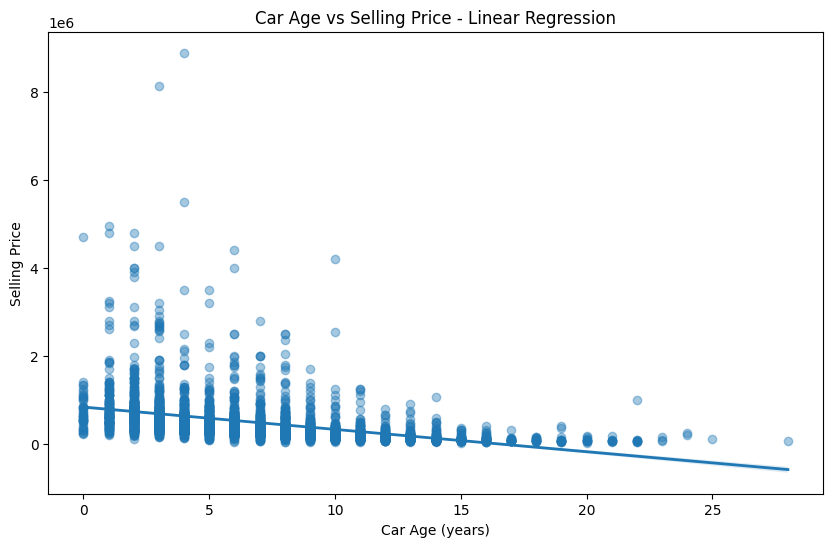

In [9]:
regression_results = age_price_regression(df)

print(f"Slope: {regression_results['slope_car_age']:,.2f}")
print(f"Intercept: {regression_results['intercept']:,.2f}")
print(f"R-squared: {regression_results['r_squared']:.3f}")
print(f"p-value: {regression_results['p_value_car_age']:.4g}")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="car_age",
    y="selling_price",
    scatter_kws={"alpha": 0.4},
    line_kws={"linewidth": 2}
)

plt.title("Car Age vs Selling Price - Linear Regression")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price")
plt.savefig(IMAGES_DIR / "03_car_age_regression.png", dpi=150, bbox_inches="tight")
plt.show()

### Regression Conclusion

The simple linear regression model found a statistically significant negative relationship between car age and selling price.

The estimated regression slope indicates that each additional year of car age is associated with an estimated decrease of approximately ₹50,820 in selling price.

The model has an R² of approximately 0.18, meaning car age alone explains about 18% of the variation in selling prices. This indicates that other factors, such as vehicle model, mileage, fuel type, transmission, and seller characteristics, also contribute substantially to price variation.

The regression demonstrates an association rather than a causal relationship.

## 05. Statistical Findings

This section summarizes the main statistical results obtained throughout the analysis.

### Key Statistical Findings

- Selling prices are right-skewed, with a mean of approximately ₹473,913 and a median of ₹350,000.
- Car age has a moderate negative correlation with selling price (r = -0.424).
- The correlation between car age and selling price is statistically significant (p < 0.001).
- Automatic vehicles have a substantially higher mean selling price than manual vehicles in this dataset.
- The difference in mean selling prices between transmission groups is statistically significant (p < 0.001).
- The Cohen's d effect size for the transmission comparison is approximately 1.97, indicating a very large standardized difference.
- Simple linear regression estimates that each additional year of car age is associated with approximately ₹50,820 lower selling price.
- Car age alone explains approximately 18% of the variation in selling prices (R² = 0.18).
- These statistical results describe associations in the dataset and do not establish causal relationships.

## Conclusion

The statistical analysis provides evidence that vehicle characteristics are associated with differences in used-car selling prices.

Car age shows a moderate negative relationship with selling price, while transmission type is associated with a substantial difference in observed prices between automatic and manual vehicles. The regression analysis further shows that car age alone explains only a portion of the variation in selling prices, highlighting the influence of additional vehicle characteristics.

Overall, the analysis demonstrates how descriptive statistics, correlation analysis, hypothesis testing, effect size, and regression can be combined to extract meaningful insights from used-car data.